In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

### 1) API HOOKUP / DATA IMPORT

In [2]:
df_test = pd.read_csv('./data/test.csv')
df = pd.read_csv('./data/train.csv')
df.head()

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


Column explanation:
- Driver – Driver code
- Compound_Encoded – Tire compound
- Year – Season of the race
- Race – Grand Prix name
- PitStop – Whether the driver pitted on that lap (0/1)
- LapNumber – Lap index within the race
- Stint – Tire stint number
- TyreLife – Number of laps on current tire
- Position – Driver's position on that lap
- LapTime (s) – Lap time in seconds
- LapTime_Delta – Change in lap time from previous lap
- Cumulative_Degradation – Accumulated tire performance drop
- RaceProgress – Fraction of race completed (0 → 1)
- Position_Change – Position gain/loss compared to previous lap

- Normalized_TyreLife (Not included) – Tire life normalized within stint

### 2) DATASET INSPECTION

In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,439140.0,219569.500000,126768.942943,0.000000,109784.75000,219569.500000,329354.250000,439139.000
Year,439140.0,2023.523544,1.024930,2022.000000,2023.00000,2024.000000,2024.000000,2025.000
PitStop,439140.0,0.136118,0.342915,0.000000,0.00000,0.000000,0.000000,1.000
LapNumber,439140.0,23.105909,16.958261,1.000000,9.00000,19.000000,36.000000,78.000
Stint,439140.0,1.789113,0.950194,1.000000,1.00000,2.000000,2.000000,8.000
TyreLife,439140.0,14.158231,9.801338,1.000000,6.00000,12.000000,20.000000,77.000
Position,439140.0,9.630339,5.278770,1.000000,5.00000,10.000000,14.000000,20.000
LapTime (s),439140.0,90.948735,19.772769,67.694000,82.62100,90.521000,98.471000,2507.607
LapTime_Delta,439140.0,-3.770040,43.945759,-2403.895000,-8.88400,-0.295000,0.115000,2423.932
Cumulative_Degradation,439140.0,-25.721759,54.766573,-274.564000,-46.56625,-20.994000,-6.199000,2412.026


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 439140 entries, 0 to 439139
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      439140 non-null  int64  
 1   Driver                  439140 non-null  object 
 2   Compound                439140 non-null  object 
 3   Race                    439140 non-null  object 
 4   Year                    439140 non-null  int64  
 5   PitStop                 439140 non-null  int64  
 6   LapNumber               439140 non-null  int64  
 7   Stint                   439140 non-null  int64  
 8   TyreLife                439140 non-null  float64
 9   Position                439140 non-null  int64  
 10  LapTime (s)             439140 non-null  float64
 11  LapTime_Delta           439140 non-null  float64
 12  Cumulative_Degradation  439140 non-null  float64
 13  RaceProgress            439140 non-null  float64
 14  Position_Change     

In [9]:
print(f"Dataset has {df.shape[0]} columns")
print(f"Dataset has {df.shape[1]} rows")
print(f"Categorical columns: {df.select_dtypes(include='object').columns.tolist()}")
print(f"Numerical columns: {df.select_dtypes(exclude='object').columns.tolist()}")
print(f"Target feature: 'PitNextLap'")

Dataset has 439140 columns
Dataset has 16 rows
Categorical columns: ['Driver', 'Compound', 'Race']
Numerical columns: ['id', 'Year', 'PitStop', 'LapNumber', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress', 'Position_Change', 'PitNextLap']
Target feature: 'PitNextLap'


### 3) MISSING VALUES / DUPLICATED ROWS

In [10]:
# Missing values
df.isnull().sum()

id                        0
Driver                    0
Compound                  0
Race                      0
Year                      0
PitStop                   0
LapNumber                 0
Stint                     0
TyreLife                  0
Position                  0
LapTime (s)               0
LapTime_Delta             0
Cumulative_Degradation    0
RaceProgress              0
Position_Change           0
PitNextLap                0
dtype: int64

In [11]:
# Duplicate rows
df[df.duplicated()]

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap


In [12]:
duplicate_keys = ["Driver", "Race", "Year", "LapNumber"]
duplicates = df[df.duplicated(subset=duplicate_keys, keep=False)]
duplicates.sort_values(duplicate_keys)

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap


Conclusions:
- No missing values to handle
- No fully identical rows, no rows with identical tuple (Driver, Race, Year, LapNumber)

### 4) EATURE EXPLORATION
#### 4.1) TARGET VARIABLE INSPECTION

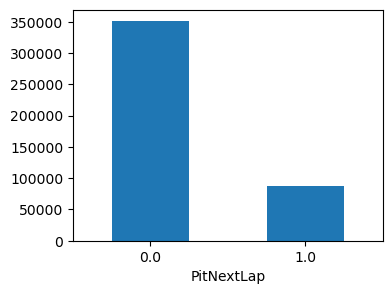

Target = 0 (80.1%), Target = 1 (19.9%)


In [17]:
fig, ax = plt.subplots(1, 1, figsize=(4,3))
df.groupby('PitNextLap').id.count().plot(kind='bar', ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.show()

percent = (df.groupby('PitNextLap').id.count() / df.shape[0]).tolist()
print(f"Target = 0 ({round(percent[0] * 100, 1)}%), Target = 1 ({round(percent[1] * 100, 1)}%)")\



Conclusion:
- Target variable ``PitNextLap`` is already in binary form (0, 1) with unbalanced proportions of 80/20

#### 4.2) CATEGORICAL VARIABLES

In [19]:
print(df.select_dtypes(include='object').columns.tolist())

['Driver', 'Compound', 'Race']


In [20]:
# Driver 
print(f"There are {df.Driver.nunique()} unique Drivers in the dataset")

There are 887 unique Drivers in the dataset


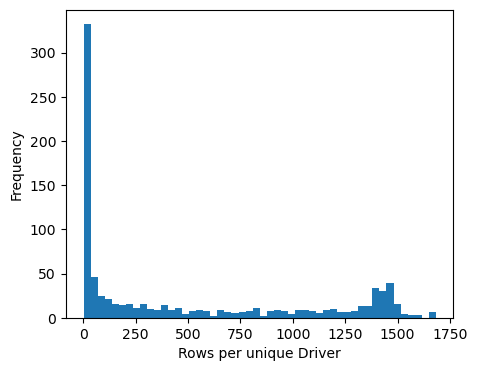

In [21]:
fig, ax = plt.subplots(1, 1, figsize=(5,4))
df.groupby('Driver').id.count().plot(kind='hist', bins=50, ax=ax)
ax.set_xlabel('Rows per unique Driver')
ax.set_ylabel('Frequency')

plt.show()

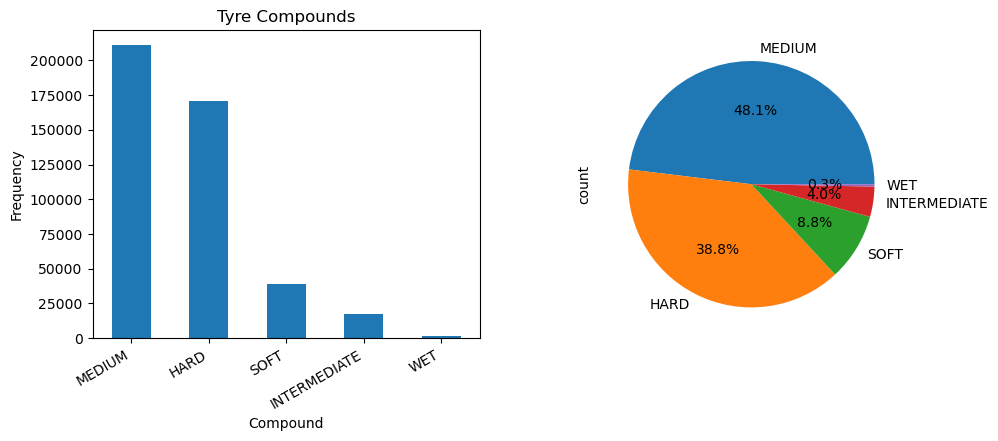

In [22]:
# Compound 
fig, ax = plt.subplots(1, 2, figsize=(11,4))
df.Compound.value_counts().plot(kind='bar', ax=ax[0])
ax[0].set_title('Tyre Compounds')
ax[0].set_xlabel('Compound')
ax[0].set_ylabel('Frequency')
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=30, ha='right')

df.Compound.value_counts().plot(kind='pie', ax=ax[1], autopct='%1.1f%%')
plt.show()

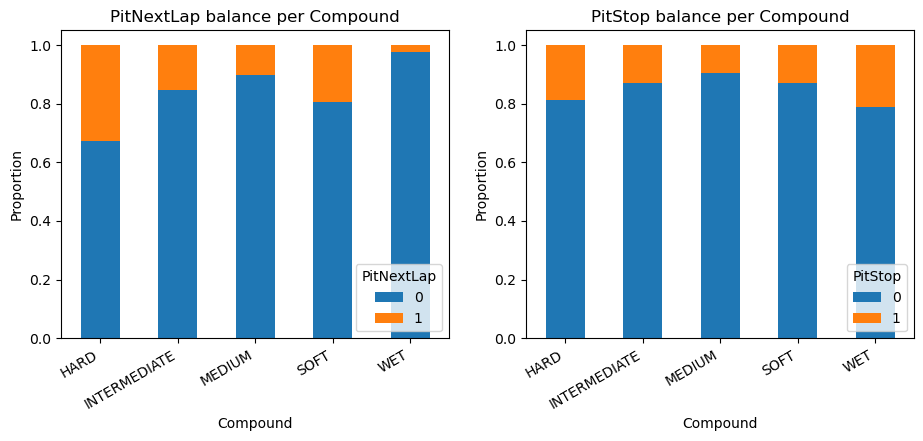

In [23]:
# Count 0s and 1s within each category
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
counts = (
    df.groupby(["Compound", "PitNextLap"])
    .size()
    .unstack(fill_value=0)
)
normalized = counts.div(counts.sum(axis=1), axis=0) # Normalize within each group
# Plot normalized stacked bars
normalized.plot(kind="bar", stacked=True, ax=ax[0])
ax[0].set_title('PitNextLap balance per Compound')
ax[0].set_xlabel("Compound")
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=30, ha='right')
ax[0].set_ylabel("Proportion")
ax[0].legend(title="PitNextLap", labels=["0", "1"], loc='lower right')

counts_pit = (
    df.groupby(['Compound', 'PitStop'])
    .size()
    .unstack(fill_value=0)
)

# Normalize within each group
normalized_pit = counts_pit.div(counts_pit.sum(axis=1), axis=0)

# Plot normalized stacked bars
normalized_pit.plot(kind="bar", stacked=True, ax=ax[1])
ax[1].set_title('PitStop balance per Compound')
ax[1].set_xlabel("Compound")
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=30, ha='right')
ax[1].set_ylabel("Proportion")
ax[1].legend(title="PitStop", labels=["0", "1"], loc='lower right')

plt.show()

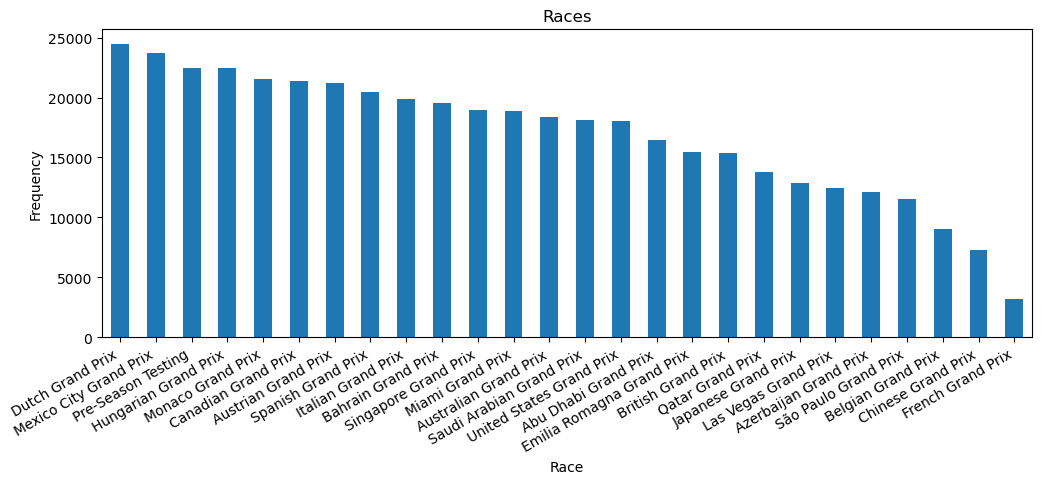

There are 25 unique Races in the dataset, in addition to the Pre-Season Testing


In [24]:
# Race 
fig, ax = plt.subplots(1, 1, figsize=(12, 4))
df.Race.value_counts().plot(kind='bar', ax=ax)
ax.set_title('Races')
ax.set_xlabel('Race')
ax.set_ylabel('Frequency')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
plt.show()

print(f"There are {df.Race.nunique()-1} unique Races in the dataset, in addition to the Pre-Season Testing")

Conclusions:
- ``Driver``: although each driver has their own style and aggressiveness, there are too many unique drivers (887) to even consider a personalized analysis, a lot of them don't have more than a handful entries in the whole dataset with median below 250

- ``Compound``: five differente types are considered, 3 are dry compounds (HARD, MEDIUM, SOFT) and 2 are wet compounds (INTERMEDIATE, WET). Most of the data is focused on the HARD (48%) and MEDIUM (39%) with wet compounds contributing only less than 5% of the total datasets. Compounds most likely affect pit strategies so it would be nice to perform individual analyses since within each compound the target variable is somewhat uniformly distributed with approximately 15-20% of the total

- ``Race``: different races come with different surfaces, temperature, and lap distances which most likely affect pit strategy, it would be nice to include additional data for each one of them. The data is nicely distributed among them with only a few races under 10k dataset entries

- We will see later that compound usage varies strongly across races:
    - `MEDIUM` and `HARD` are the most consistently used compounds across races
    - `SOFT` usage is highly race-dependent
    - `INTERMEDIATE` and `WET` tyres are sparse and appear only in selected races due to random weather factors

#### 4.3) NUMERICAL VARIABLES

In [26]:
print(df.select_dtypes(exclude='object').columns.tolist())

['id', 'Year', 'PitStop', 'LapNumber', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress', 'Position_Change', 'PitNextLap']


In [27]:
# Validate expected ranges for specific numerical variables
checks = {
    "LapNumber_positive": (df["LapNumber"] > 0).all(),
    "Stint_positive": (df["Stint"] > 0).all(),
    "TyreLife_non_negative": (df["TyreLife"] >= 0).all(),
    "Position_positive": (df["Position"] >= 1).all(),
    "LapTime_positive": (df["LapTime (s)"] > 0).all(),
    "RaceProgress_between_0_and_1": df["RaceProgress"].between(0, 1).all(),
    "Position_Change_between_neg25_pos25": ((df['Position_Change'] > -25) & (df['Position_Change'] < 25)).all(),
}
checks

{'LapNumber_positive': np.True_,
 'Stint_positive': np.True_,
 'TyreLife_non_negative': np.True_,
 'Position_positive': np.True_,
 'LapTime_positive': np.True_,
 'RaceProgress_between_0_and_1': np.True_,
 'Position_Change_between_neg25_pos25': np.True_}

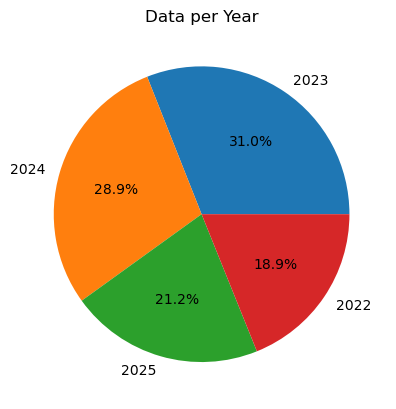

In [28]:
# Year
df.Year.value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Data per Year')
plt.ylabel('')
plt.show()

/tmp/ipykernel_256924/1486740258.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["LapNumber_bin", "PitNextLap"])


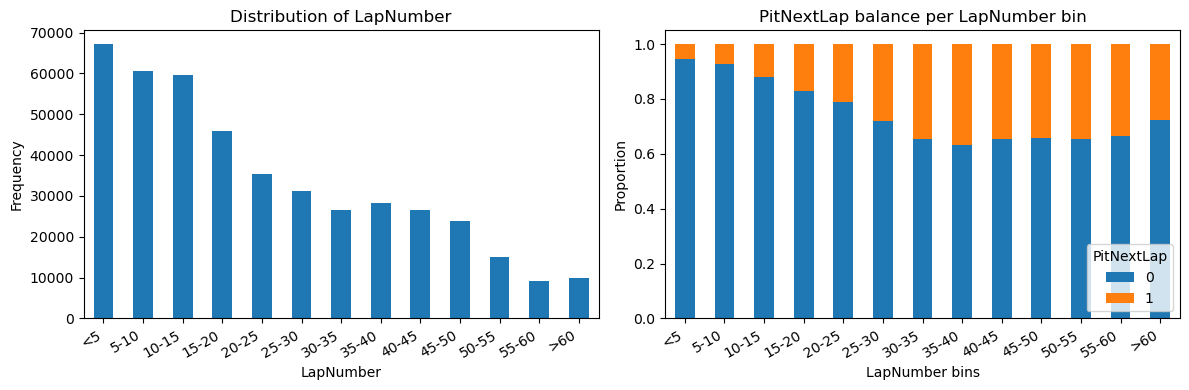

In [30]:
# LapNumber
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
# Define LapNumber bins
lap_labels = ['<5', '5-10', '10-15', '15-20', '20-25', '25-30', '30-35', '35-40', '40-45', '45-50', '50-55', '55-60', '>60']
df["LapNumber_bin"] = pd.cut(
    df.LapNumber,
    bins=[0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 100],
    labels=lap_labels
)
# Plot 1: LapNumber distribution
LapNumber = df["LapNumber_bin"].value_counts(sort=False)
LapNumber.plot(kind='bar', ax=ax[0])
ax[0].set_title('Distribution of LapNumber')
ax[0].set_xlabel('LapNumber')
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=30, ha='right')
ax[0].set_ylabel('Frequency')

# Plot 2: PitNextLap proportion by LapNumber bins
counts = (
    df.groupby(["LapNumber_bin", "PitNextLap"])
    .size()
    .unstack(fill_value=0)
)
# Force x-axis order
counts = counts.reindex(lap_labels)
normalized = counts.div(counts.sum(axis=1), axis=0) # Normalize within each LapNumber bin
normalized.plot(kind="bar", stacked=True, ax=ax[1])
ax[1].set_title("PitNextLap balance per LapNumber bin")
ax[1].set_xlabel("LapNumber bins")
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=30, ha='right')
ax[1].set_ylabel("Proportion")
ax[1].legend(title="PitNextLap", labels=["0", "1"], loc='lower right')
plt.tight_layout()
plt.show()

# Discard the temporary LapNumberBin column
df.drop(columns=['LapNumber_bin'], inplace=True)

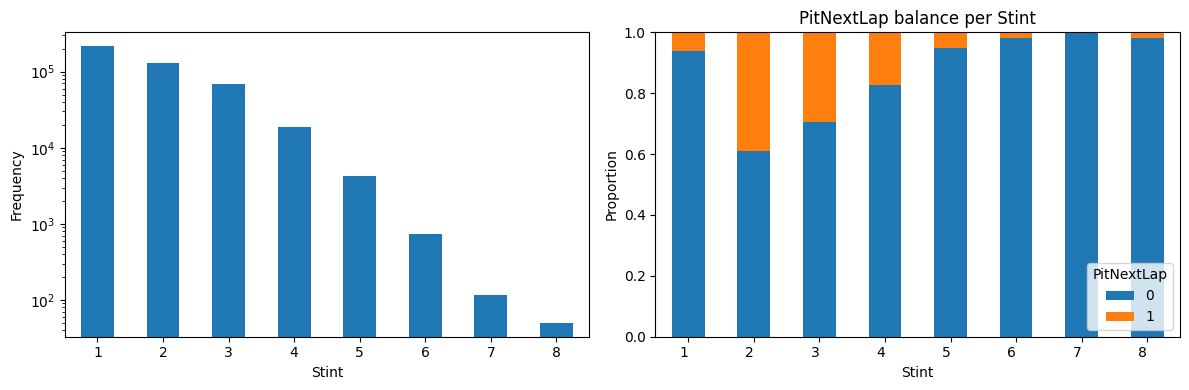

In [217]:
# Stint 
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df.Stint.value_counts().plot(kind='bar', ax=ax[0])
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=0)
ax[0].set_ylabel('Frequency')
ax[0].set_yscale('log')

counts = (
    df.groupby(["Stint", "PitNextLap"])
    .size()
    .unstack(fill_value=0)
)
# Normalize within each Stint
normalized = counts.div(counts.sum(axis=1), axis=0)
normalized.plot(kind="bar", stacked=True, ax=ax[1])
ax[1].set_title("PitNextLap balance per Stint")
ax[1].set_xlabel("Stint")
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=0, ha='right')
ax[1].set_ylabel("Proportion")
ax[1].legend(title="PitNextLap", labels=["0", "1"], loc='lower right')

plt.tight_layout()
plt.show()

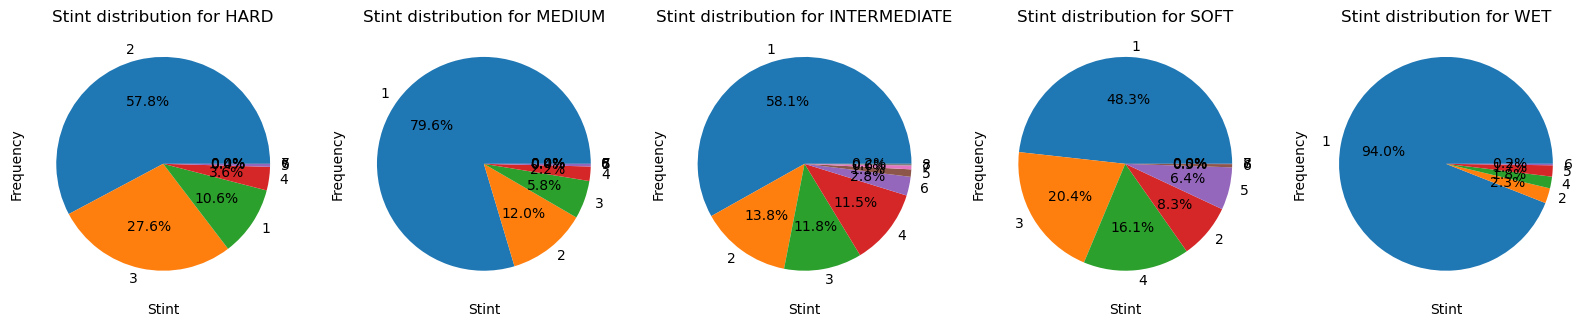

In [31]:
nComp = df.Compound.nunique()
fig, ax = plt.subplots(1, nComp, figsize=(4*nComp, 4), sharex=True)

for i, Compound in enumerate(df.Compound.unique()):
    df[df.Compound == Compound].Stint.value_counts().plot(kind='pie', autopct='%1.1f%%', ax=ax[i])
    ax[i].set_title(f'Stint distribution for {Compound}')
    ax[i].set_xlabel('Stint')
    ax[i].set_ylabel('Frequency')
plt.show()


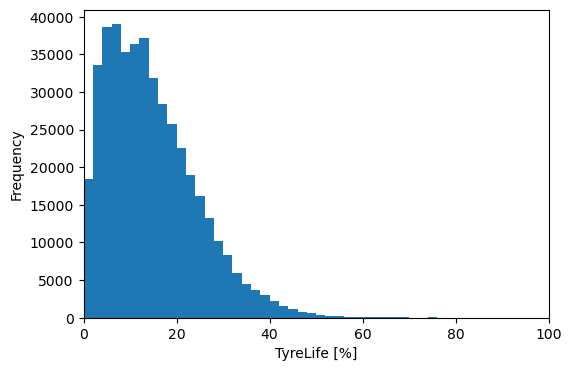

In [32]:
# TyreLife
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
df.TyreLife.plot(kind='hist', bins=50, range=(0,100), ax=ax)
ax.set_xlim(0, 100)
ax.set_xlabel('TyreLife [%]')

plt.show()

/tmp/ipykernel_256924/1331521010.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=30, ha="right")


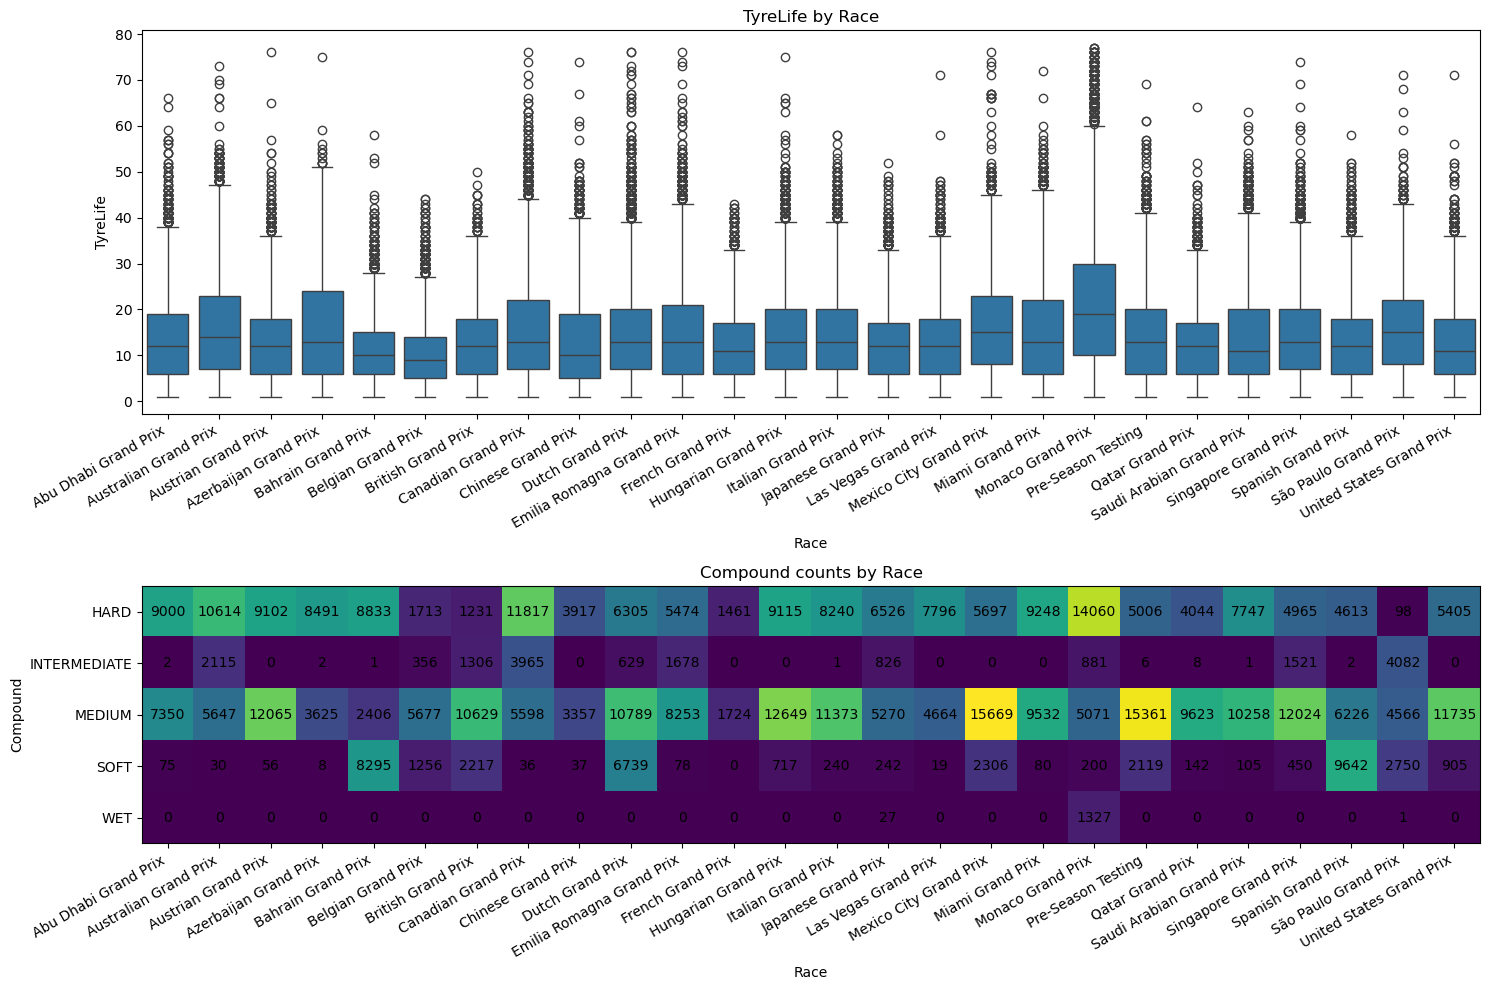

In [33]:
# Force a consistent Race order
Race_order = sorted(df["Race"].drop_duplicates().tolist())
fig, ax = plt.subplots(2, 1, figsize=(15, 10))
# Plot 1: Boxplot ordered by Race
sns.boxplot(
    data=df,
    x="Race",
    y="TyreLife",
    order=Race_order,
    ax=ax[0]
)
ax[0].set_title("TyreLife by Race")
ax[0].set_xlabel("Race")
ax[0].set_ylabel("TyreLife")
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=30, ha="right")

# Plot 2: Compound count matrix ordered by Race
matrix = pd.crosstab(df["Compound"], df["Race"])
# Reorder matrix columns to match the boxplot Race order
matrix = matrix.reindex(columns=Race_order, fill_value=0)
im = ax[1].imshow(matrix)
ax[1].set_xticks(range(len(matrix.columns)))
ax[1].set_yticks(range(len(matrix.index)))
ax[1].set_xticklabels(matrix.columns, rotation=30, ha="right")
ax[1].set_yticklabels(matrix.index)
ax[1].set_xlabel("Race")
ax[1].set_ylabel("Compound")
ax[1].set_title("Compound counts by Race")
# Add counts inside cells
for i in range(len(matrix.index)):
    for j in range(len(matrix.columns)):
        ax[1].text(
            j,
            i,
            matrix.iloc[i, j],
            ha="center",
            va="center"
        )
plt.tight_layout()
plt.show()

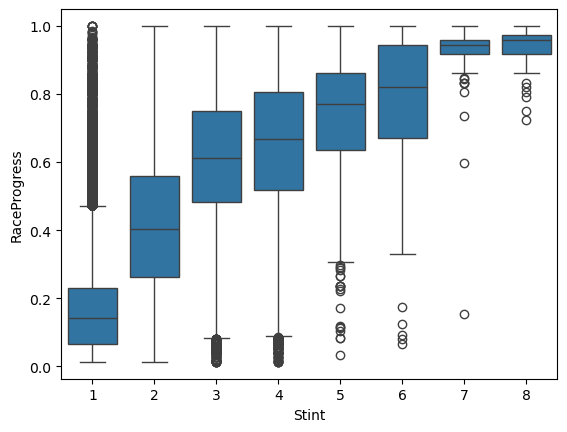

In [34]:
# RaceProgress
sns.boxplot(x='Stint', y='RaceProgress', data=df)
plt.show()

In [35]:
# LapTime (s)
df[df['LapTime (s)'] > 2000]

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
67979,67979,D047,MEDIUM,Austrian Grand Prix,2023,0,2,1,2.0,1,2473.241,23.820,2377.540,0.028169,0.0,0.0
73750,73750,D150,MEDIUM,Monaco Grand Prix,2025,0,1,1,1.0,3,2473.273,24.272,11.978,0.012821,-2.0,0.0
175487,175487,BRA,MEDIUM,Belgian Grand Prix,2024,0,1,1,1.0,2,2387.902,2423.932,7.824,0.012821,3.0,0.0
183041,183041,FON,HARD,Monaco Grand Prix,2024,1,1,1,1.0,4,2497.268,24.080,2370.062,0.012821,-2.0,0.0
237295,237295,FIS,HARD,Monaco Grand Prix,2024,1,1,1,2.0,13,2497.678,2406.326,2383.678,0.013158,-7.0,0.0
245155,245155,MAL,MEDIUM,Monaco Grand Prix,2024,0,1,1,1.0,8,2502.809,24.926,2385.714,0.012987,1.0,0.0
248029,248029,BUE,HARD,Monaco Grand Prix,2024,0,1,1,1.0,17,2502.648,19.937,2390.333,0.013158,-13.0,0.0
255988,255988,PIQ,HARD,Monaco Grand Prix,2024,0,1,1,1.0,11,2488.609,23.734,2381.300,0.013158,-4.0,0.0
256648,256648,HAR,HARD,Monaco Grand Prix,2024,0,1,1,1.0,7,2488.809,24.926,2383.678,0.012821,-5.0,0.0
262674,262674,D019,MEDIUM,Monaco Grand Prix,2025,0,1,1,2.0,4,2473.461,15.976,24.733,0.012821,0.0,0.0


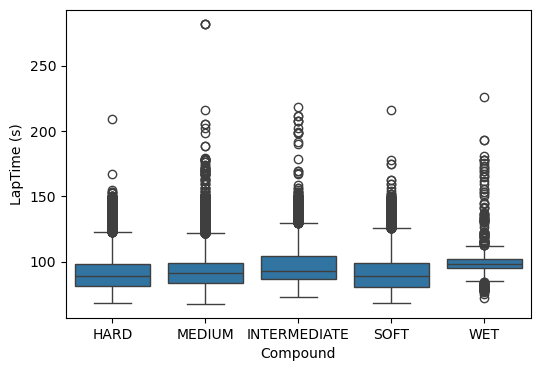

In [36]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
sns.boxplot(data=df[df['LapTime (s)'] < 2000], x='Compound', y='LapTime (s)', ax=ax)
plt.show()

/tmp/ipykernel_256924/2993676184.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=30, ha="right")


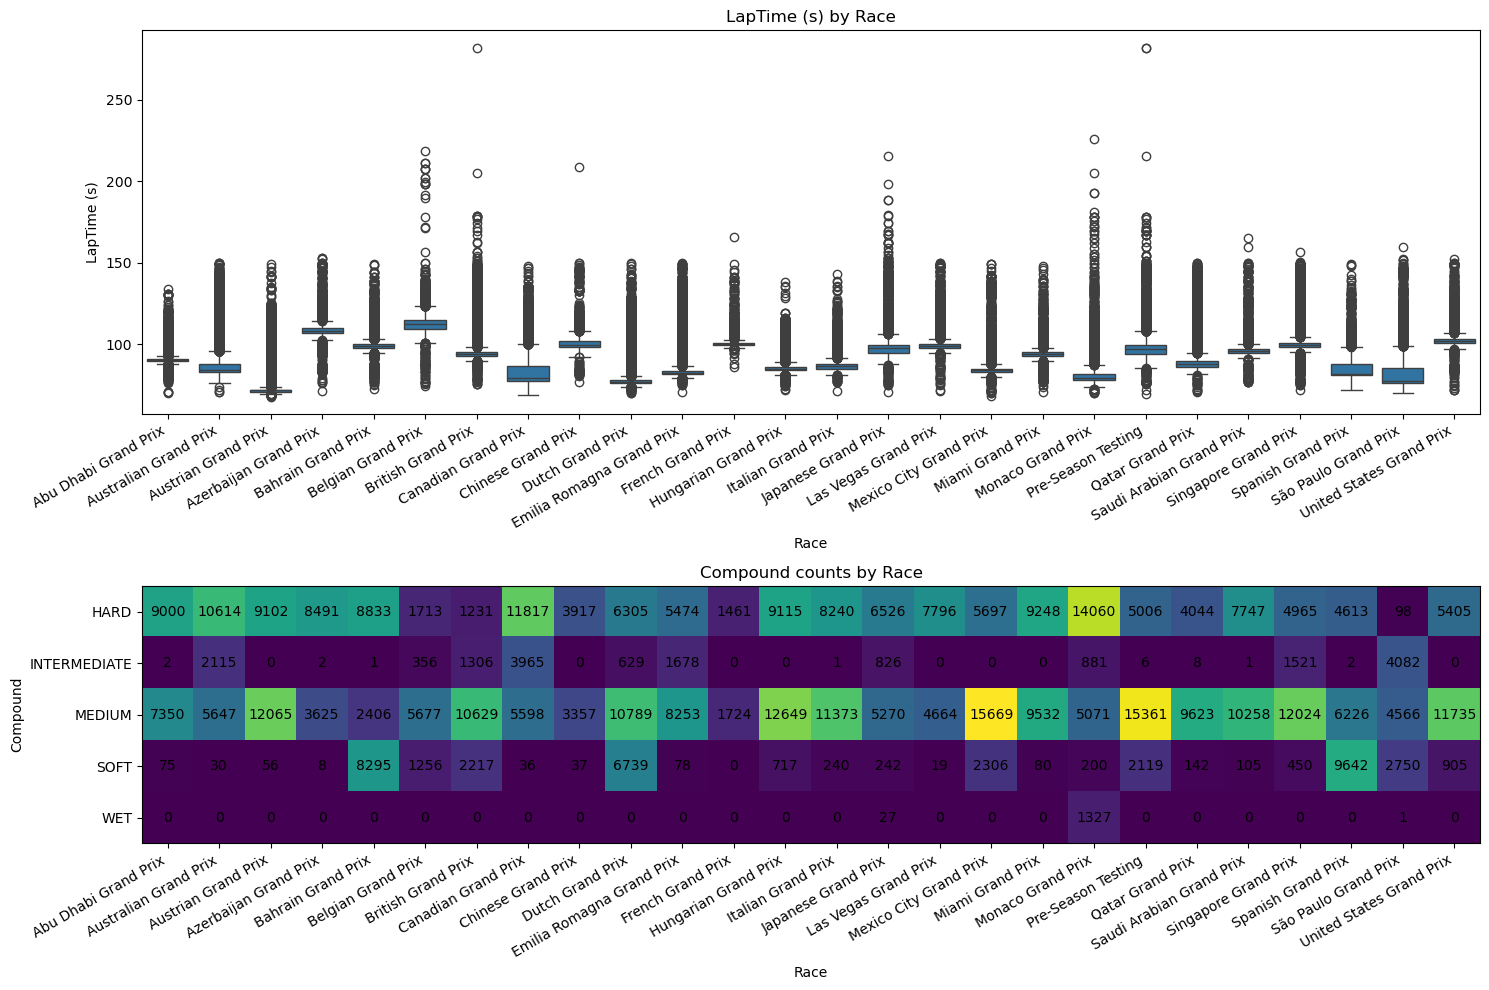

In [37]:
# Force a consistent Race order
Race_order = sorted(df["Race"].drop_duplicates().tolist())
fig, ax = plt.subplots(2, 1, figsize=(15, 10))

# Plot 1: Boxplot ordered by Race
sns.boxplot(
    data=df[df['LapTime (s)'] < 2000],
    x="Race",
    y="LapTime (s)",
    order=Race_order,
    ax=ax[0]
)
ax[0].set_title("LapTime (s) by Race")
ax[0].set_xlabel("Race")
ax[0].set_ylabel("LapTime (s)")
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=30, ha="right")


# Plot 2: Compound count matrix ordered by Race
matrix = pd.crosstab(df["Compound"], df["Race"])
# Reorder matrix columns to match the boxplot Race order
matrix = matrix.reindex(columns=Race_order, fill_value=0)
im = ax[1].imshow(matrix)
ax[1].set_xticks(range(len(matrix.columns)))
ax[1].set_yticks(range(len(matrix.index)))
ax[1].set_xticklabels(matrix.columns, rotation=30, ha="right")
ax[1].set_yticklabels(matrix.index)
ax[1].set_xlabel("Race")
ax[1].set_ylabel("Compound")
ax[1].set_title("Compound counts by Race")
# Add counts inside cells
for i in range(len(matrix.index)):
    for j in range(len(matrix.columns)):
        ax[1].text(
            j,
            i,
            matrix.iloc[i, j],
            ha="center",
            va="center"
        )
plt.tight_layout()
plt.show()

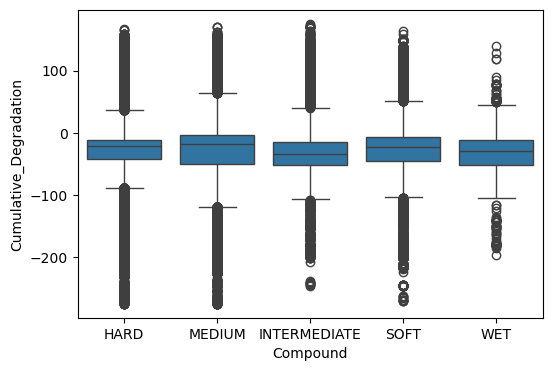

In [39]:
# Cumulative_Degradation
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
sns.boxplot(data=df[df.Cumulative_Degradation < 2000], x='Compound', y='Cumulative_Degradation', ax=ax)
plt.show()

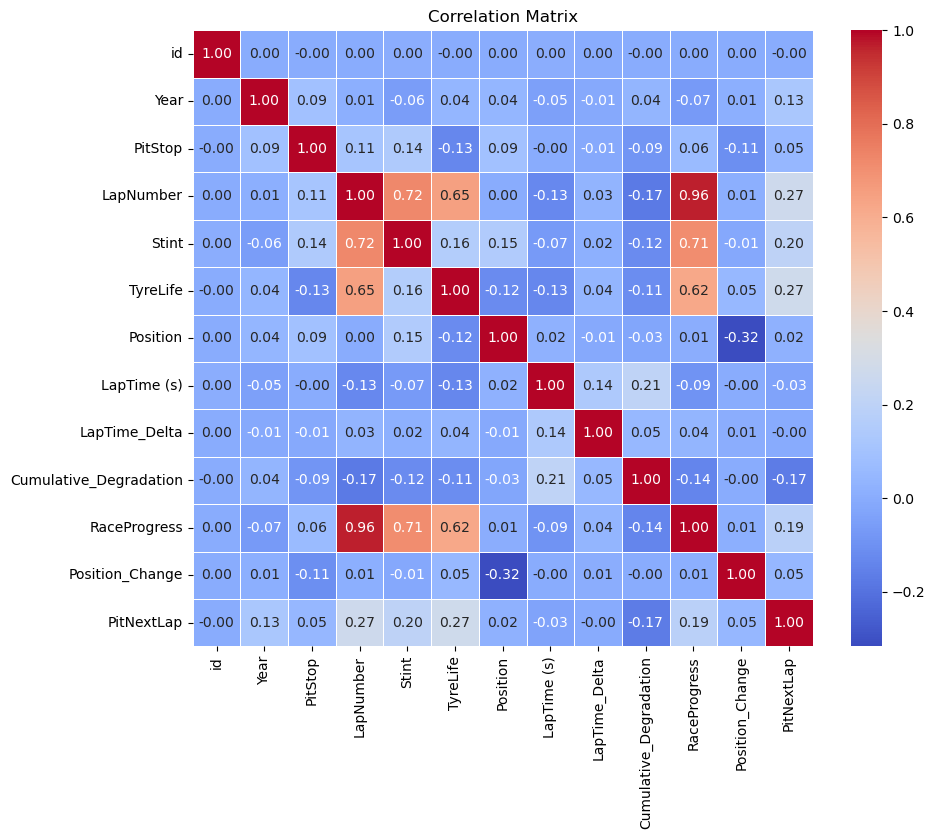

In [41]:
# Covariance matrix of numerical variables
matrix = df[df.select_dtypes(exclude='object').columns.tolist()].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

Conclusions: 
- ``Year``: dataset is distributed across four years: 2022 (19%), 2023 (31%), 2024 (29%), and 2025 (21%), all years are represented with meaningful sample sizes

- ``LapNumber``: Most observations occur in the early part of races, especially before lap 15, with later lap bins, especially `55-60` and `>60`, contain much fewer observations pointing toward data concentrated around early and mid-race. The target variable `PitNextLap` is highly imbalanced across all lap-number bins as the proportion of `PitNextLap = 1` increases as lap number increases

- ``Stint``: the frequency of data decreases sharply as stint number increases with stints 7 and 8 being rare compared to earlier stints probably due to specific pit strategies and compound choices. Stint 2 shows the highest relative proportion of `PitNextLap = 1`, as the target balance varies substantially across stints, `Stint` may carry useful training information. Note that stint distribution differs clearly by tyre compound:
    - `HARD` tyres are mostly used in stint 2
    - `MEDIUM` tyres are mostly used in stint 1, suggesting they are frequently used at the start of races
    - `SOFT` tyres are more evenly spread across stints 1 to 5 compared with other dry compounds
    - `INTERMEDIATE` tyres are mainly used in stint 1
    - `WET` tyres are overwhelmingly used in stint 1

- ``TyreLife``: most observations have tyre life below 30% with very high tyre life values above 50% being rare. Either tyres are changed before reaching 60% or little data is provided for further usage. Tyre life varies noticeably across races:
    - Some races, such as pre-season testing, show higher tyre life values and wider spreads, this might be the result actual testing of the tyre life cycle and compounds
    - Several races contain many high tyre life outliers above 50%
    - Track characteristics and race strategy affect tyre life, as races with more HARD compound usage is likely to achieved higher tyre life

- ``RaceProgress``: is highly correlated with number of stint as expected, with Stint 1 at the beginning of the race and Stint 7 and 8 toward the very late phases

- ``LapTime (s)``: differ by compound with wet compunds generally showing higher median lap times than dry ones. There are many high-lap-time outliers across all compounds, possibly due to pit laps, safety cars, traffic, abnormal race situations. A handful of entries in the dataset has lap time > 2000 which is longer than 30 min. There all appear in the first or second lap of the race potentially referring to crashes at the beginning of the race. Lap-time distributions vary strongly across races as expected due to naturally different track lengths

- ``Cumulative_Degradation``: The median cumulative degradation appears negative for all compounds, while tyres might gain performance as they warm up (>0), overall it would make sense to lose performance (<0) due to natural wear.

#### Correlation Matrix
Highly correlated variables:
- LapNumber and RaceProgress: corr > 0.95
- LapNumber and Sting: corr > 0.7
- LapNumber and TyreLife: corr > 0.65
- TyreLife and RaceProgress: corr > 0.62
- Position_Change and Position: corr < -0.32

#### 4.4) PERFORMANCE INVESTIGATION

In [45]:
def plot_median_iqr(df, x_col, y_col="LapTime (s)", xlabel=None, title=None):
    """
    Plot median lap time with 25th-75th percentile error bars
    """
    data = (
        df.groupby(x_col, observed=True)[y_col]
        .agg(
            median_lap="median",
            perc_25=lambda x: np.percentile(x, 25),
            perc_75=lambda x: np.percentile(x, 75),
        )
        .reset_index()
    )
    data["lower_error"] = data["median_lap"] - data["perc_25"]
    data["upper_error"] = data["perc_75"] - data["median_lap"]

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.errorbar(
        x=data.index,
        y=data["median_lap"],
        yerr=[data["lower_error"], data["upper_error"]],
        fmt="o",
        capsize=4,
    )
    ax.set_xticks(data.index)
    ax.set_xticklabels(data[x_col], rotation=30, ha='right')
    ax.set_xlabel(xlabel if xlabel else x_col)
    ax.set_ylabel("Median LapTime [s]")
    ax.set_title(title if title else f"Lap Time vs {x_col}")
    plt.tight_layout()
    plt.show()

    return data

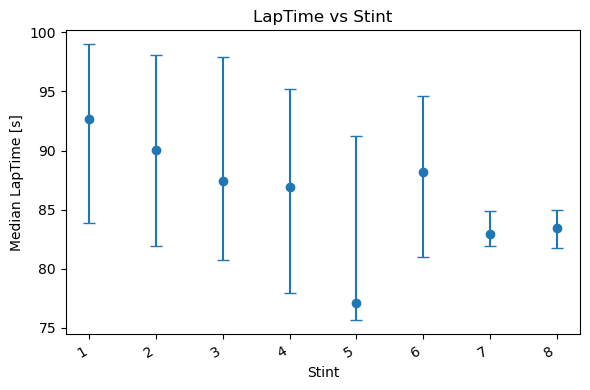

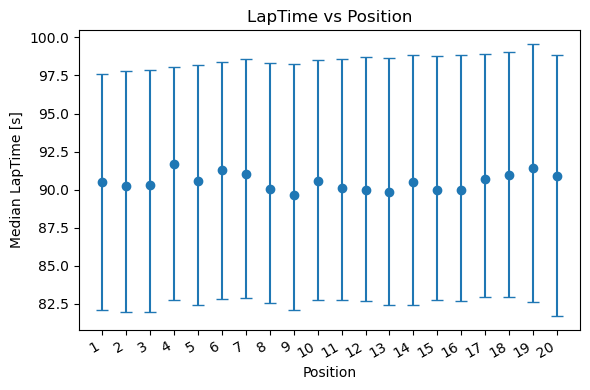

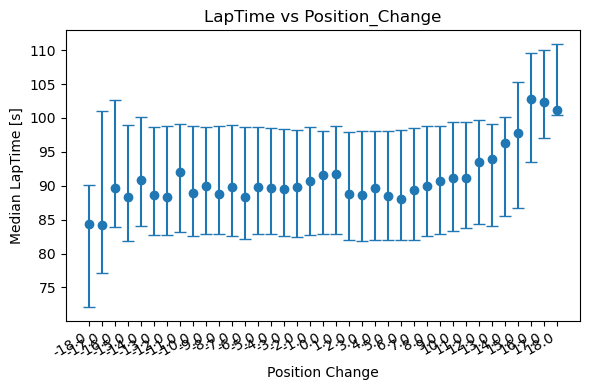

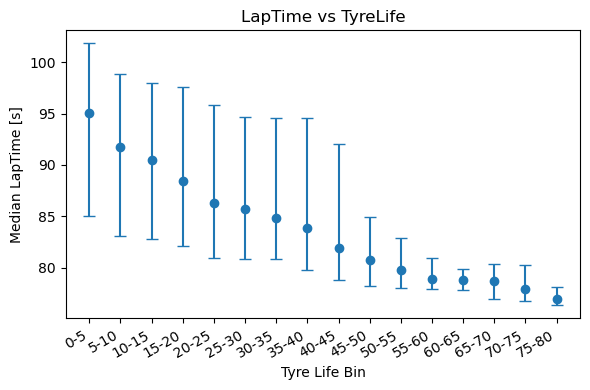

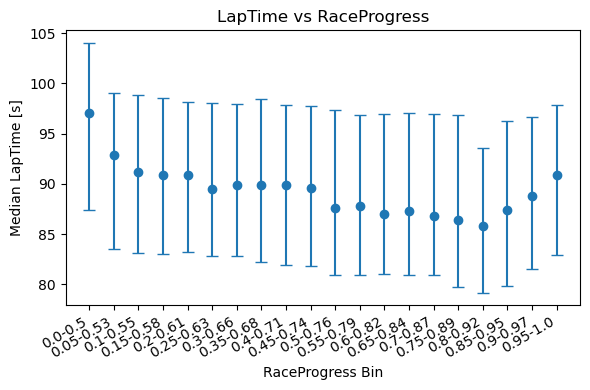

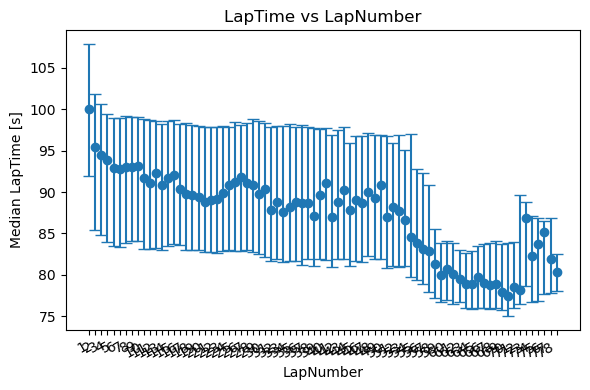

In [46]:
# LapTime vs Stint
stint_data = plot_median_iqr(
    df=df,
    x_col="Stint",
    xlabel="Stint",
    title="LapTime vs Stint",
)

# LapTime vs Position
position_data = plot_median_iqr(
    df=df,
    x_col="Position",
    xlabel="Position",
    title="LapTime vs Position",
)

# LapTime vs PositionChange
position_change_data = plot_median_iqr(
    df=df,
    x_col="Position_Change",
    xlabel="Position Change",
    title="LapTime vs Position_Change",
)

# LapTime vs TyreLife
df["TyreLife_bin"] = pd.cut(df["TyreLife"], 
                             bins=np.arange(0, 105, 5), 
                             labels=[f'{x}-{y}' for x,y in zip(np.arange(0, 100, 5), np.arange(5, 105, 5))])
tyre_life_data = plot_median_iqr(
    df=df,
    x_col="TyreLife_bin",
    xlabel="Tyre Life Bin",
    title="LapTime vs TyreLife",
)

# LapTime vs RaceProgress
df["RaceProgress_bin"] = pd.cut(df["RaceProgress"], 
                                 bins=np.linspace(0, 1, 21),
                                 labels=[f'{round(x, 2)}-{round(y, 2)}' for x,y in zip(np.linspace(0, 0.95, 20), np.linspace(0.5, 1, 20))])
race_progress_data = plot_median_iqr(
    df=df,
    x_col="RaceProgress_bin",
    xlabel="RaceProgress Bin",
    title="LapTime vs RaceProgress",
)

# LapTime vs lap_number
position_data = plot_median_iqr(
    df=df,
    x_col="LapNumber",
    xlabel="LapNumber",
    title="LapTime vs LapNumber",
)


/tmp/ipykernel_256924/2359990259.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')


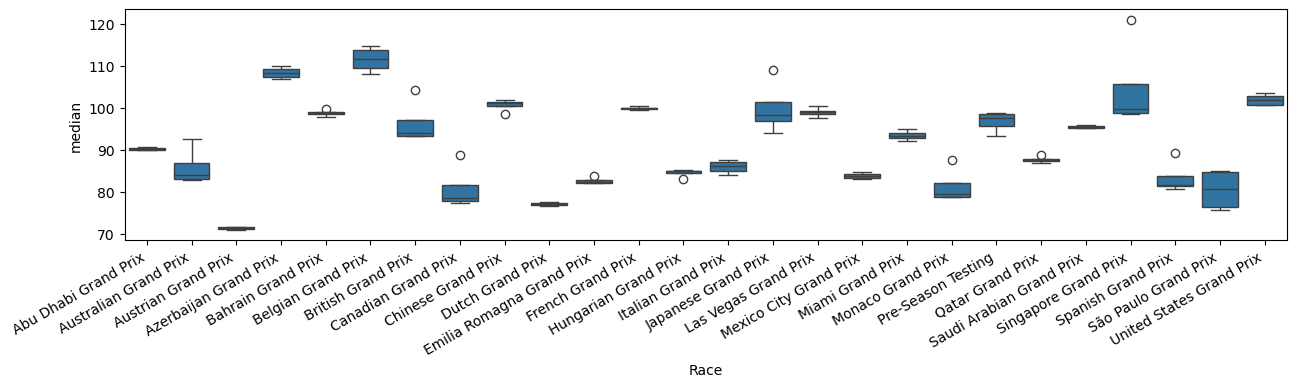

In [47]:
# LapTime per (Race, Year)
lap_race = df.groupby(['Race', 'Year'])['LapTime (s)'].median().reset_index(name='median')

fig, ax = plt.subplots(1, 1, figsize=(15, 3))
sns.boxplot(data=lap_race, x='Race', y='median', ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
plt.show()

Conclusions: 
- Stint 1 has the highest median lap time due to the starting lap with higher traffic and colder tyres, this can be observed in the median time per lap. Later laps and stints seem to achieve the best median lap times compared to early race laps. This is also visible in median lap time vs race progress.

- Median lap time results fairly stable across positions 1 to 20. There is no strong visual evidence that race position alone explains large differences in lap time.

- Large positive position changes are associated with large median lap time changes, this can be observed for many positions lost and many positions gained. Smaller position changes are associated with more stable median lap times.

- The highest median lap times occur in the lowest tyre-life bin, especially `0-5`, potentially due to colder tyres, higher traffic at the beginning of the race where everyone has new tyres, and more fueled being carried by the cars. From `0-5` to approximately `50-55`, there is a clear downward trend in median lap time. Since tyres usually degrade with usage, the decreasing lap time suggests that `TyreLife` is confounded with race phase and fuel load, as worn tyres should intuitively show worse lap times.

- Median lap time differs substantially by race due to different length, characteristics, and strategies.

#### 4.5) PITTING STRATEGY

/tmp/ipykernel_256924/3741715788.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("RaceProgress_bin")["PitNextLap"]


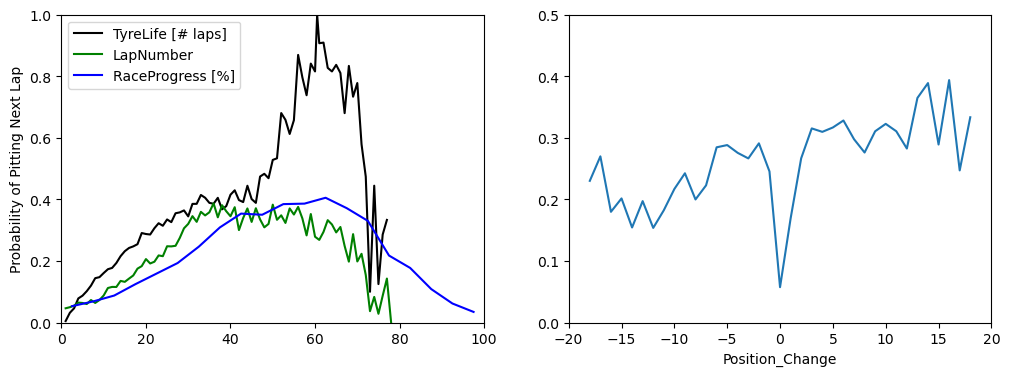

In [48]:
# PitNextLap vs TyreLife
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
data = df.groupby('TyreLife')['PitNextLap'].mean()
ax[0].plot(data.index, data.values, color='black', label='TyreLife [# laps]')

# PitNextLap vs LapNumber
data = df.groupby('LapNumber')['PitNextLap'].mean()
ax[0].plot(data.index, data.values, color='green', label='LapNumber')

# PitNextLap vs RaceProgress
pit_prob = (
    df.groupby("RaceProgress_bin")["PitNextLap"]
    .mean()
)
ax[0].plot(np.linspace(2.5, 97.5, 20), pit_prob.values, color='blue', label='RaceProgress [%]')
ax[0].set_xlabel("")
ax[0].set_ylabel("Probability of Pitting Next Lap")
ax[0].set_xlim(0, 100)
ax[0].set_ylim(0, 1)
ax[0].legend()

df.groupby('Position_Change')['PitNextLap'].mean().plot(ax=ax[1])
ax[1].set_xlim(-20, 20)
ax[1].set_ylim(0, 0.5)

plt.show()


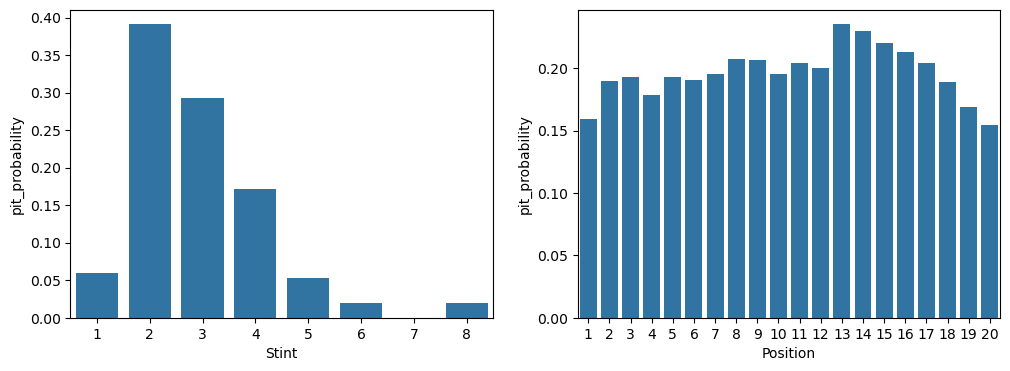

In [50]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# PitNextLap vs Stint
pit_data = (
    df.groupby('Stint')["PitNextLap"]
    .mean()
    .reset_index(name="pit_probability")
)
sns.barplot(
    data=pit_data,
    x='Stint',
    y="pit_probability",
    ax=ax[0],
)
# PitNextLap vs Position
pit_data = (
    df.groupby('Position')["PitNextLap"]
    .mean()
    .reset_index(name="pit_probability")
)
sns.barplot(
    data=pit_data,
    x='Position',
    y="pit_probability",
    ax=ax[1],
)
plt.show()

In [51]:
df.drop(columns=['TyreLife_bin', 'RaceProgress_bin'], inplace=True)

Conclusions:
- The probability of pitting on the next lap increases strongly with `TyreLife`, the probability rises gradually early on, then peaks around the 55-65 laps. After very high tyre-life values the probability drops sharply. This is also observed for `LapNumber` with a plateau between lap 40 and 60, and `RaceProgress`. Later phases of the race don't see many pits as all race strategies try to end the race by calculating the minimum excess of tyres, and fuel.

- Around zero position change, there is a visible dip in pit probability, this may reflect pit-cycle effects, where position changes are influenced by other drivers stopping and strategy offsets. In addition, many lost positions might be associated with mechanical problems forcing a pit.

- Pit probability is highest in stint 2, wiht Stint 3 also showing a relatively high probability of pitting on the next lap.

- Pit probability is relatively stable across race positions, in a way every one is forced to pit eventually

### 5) FEATURE ENGINEERING

In [ ]:
def add_pit_prediction_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Feature engineering to improve prediction of PitNextLap
    """
    df = df.copy()

    race_keys = ["Year", "Race"]
    sequence_keys = ["Year", "Race", "Driver", "Stint"]

    # Feature 1: LapsRemaining
    # Why: pit probability depends on how much race distance is left
    df["TotalRaceLaps"] = df.groupby(race_keys)["LapNumber"].transform("max")
    df["LapsRemaining"] = df["TotalRaceLaps"] - df["LapNumber"]

    # Feature 2: TyreLifeSquared
    # Why: tyre life effect is nonlinear
    df["TyreLifeSquared"] = df["TyreLife"] ** 2

    # Feature 3: RaceMedianLapTime and LapTimeVsRaceMedian
    # Why: tries to normalize lap time against race-specific time
    df["RaceMedianLapTime"] = df.groupby(race_keys)["LapTime (s)"].transform("median")
    df["LapTimeVsRaceMedian"] = df["LapTime (s)"] - df["RaceMedianLapTime"]

    # Feature 4: RecentLapTimeMean_3 and RecentLapTimeTrend
    # Why: change in performance may trigger pit call
    row_order_col = "__row_order__"
    df[row_order_col] = np.arange(len(df))
    ordered = df.sort_values(sequence_keys + ["LapNumber", "id"]).copy()
    grouped_lap_time = ordered.groupby(sequence_keys)["LapTime (s)"]
    previous_laps = pd.concat(
        [grouped_lap_time.shift(lag) for lag in [1, 2, 3]],
        axis=1,
    )
    recent_mean = previous_laps.mean(axis=1)
    ordered["RecentLapTimeMean_3"] = recent_mean.fillna(ordered["LapTime (s)"])
    ordered["RecentLapTimeTrend"] = ordered["LapTime (s)"] - ordered["RecentLapTimeMean_3"]
    ordered = ordered.sort_values(row_order_col).drop(columns=row_order_col)

    return ordered


In [53]:
df = add_pit_prediction_features(df)

### 6) TRAIN BENCHMARK MODEL USING kNN 
In this phase, the idea is to train a single model for each compound, wet compounds are merged together due to the very limited amount of data for the WET compound. The use of kNN allows us to have a benchmark of the prediction performance using cross-validation

For this model, some features will be excluded (e.g. Driver, Year, ...) while some features will be scaled using the StandardScaler (e.g. LapTime (s), LapTime_Delta, Cumulative_Degradation)

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


def add_compound_model_group(df: pd.DataFrame) -> pd.DataFrame:
    """
    Merge WET and INTERMEDIATE compounds
    """
    df = df.copy()
    df["Compound_Model"] = df["Compound"].replace(
        {
            "WET": "WET_LIKE",
            "INTERMEDIATE": "WET_LIKE",
        }
    )
    return df


def stratified_sample_for_benchmark(
    df: pd.DataFrame,
    target_col: str,
    max_samples: int | None,
    random_state: int,
) -> pd.DataFrame:
    """
    kNN benchmark with downsample for speed
    """
    if max_samples is None or len(df) <= max_samples:
        return df.copy()

    positive_rate = df[target_col].mean()
    n_positive = max(1, int(round(max_samples * positive_rate)))
    n_negative = max_samples - n_positive

    positives = df[df[target_col] == 1]
    negatives = df[df[target_col] == 0]

    n_positive = min(n_positive, len(positives))
    n_negative = min(n_negative, len(negatives))

    sampled = pd.concat(
        [
            positives.sample(n=n_positive, random_state=random_state),
            negatives.sample(n=n_negative, random_state=random_state),
        ],
        axis=0,
    )

    return sampled.sample(frac=1, random_state=random_state).reset_index(drop=True)


def build_compound_knn_models(
    df: pd.DataFrame,
    k_values: list[int] | None = None,
    n_splits: int = 5,
    random_state: int = 42,
    max_samples_per_compound: int | None = 10_000,
) -> tuple[dict, pd.DataFrame]:
    """
    Train one kNN benchmark model per compound group

    WET and INTERMEDIATE are merged into WET_LIKE because WET has a low number of
    positive PitNextLap cases
    ROC-AUC is maximized with GridSearchCV
    """

    if k_values is None:
        k_values = np.arange(15, 41, 2)

    target_col = "PitNextLap"
    df = add_compound_model_group(df)

    excluded_cols = [
        "id",
        "Driver",
        "Year",
        "Race",
        "Compound",
        "Compound_Model",
        "PitStop",
        target_col,
    ]

    feature_cols = [
        col for col in df.columns
        if col not in excluded_cols
        and pd.api.types.is_numeric_dtype(df[col])
    ]

    models = {}
    results = []

    for compound_model in sorted(df["Compound_Model"].dropna().unique()):
        source_df = df[df["Compound_Model"] == compound_model].copy()
        compound_df = stratified_sample_for_benchmark(
            source_df,
            target_col=target_col,
            max_samples=max_samples_per_compound,
            random_state=random_state,
        )

        X = compound_df[feature_cols]
        y = compound_df[target_col].astype(int)

        n_source_samples = len(source_df)
        n_samples = len(compound_df)
        n_positive = int(y.sum())
        n_negative = int((y == 0).sum())

        if y.nunique() < 2:
            print(f"Skipping {compound_model}: target has only one class")
            continue

        cv_splits = min(n_splits, n_positive, n_negative)
        if cv_splits < 2:
            print(f"Skipping {compound_model}: not enough samples for CV")
            continue

        cv = StratifiedKFold(
            n_splits=cv_splits,
            shuffle=True,
            random_state=random_state,
        )

        min_train_size = int(n_samples * (cv_splits - 1) / cv_splits)
        valid_k_values = [k for k in k_values if k <= min_train_size]
        if not valid_k_values:
            print(f"Skipping {compound_model}: no valid k values for sample size")
            continue

        pipeline = Pipeline(
            steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                ("model", KNeighborsClassifier()),
            ]
        )

        search = GridSearchCV(
            estimator=pipeline,
            param_grid={"model__n_neighbors": valid_k_values},
            scoring="roc_auc",
            cv=cv,
            n_jobs=-1,
            refit=True,
            return_train_score=True,
        )
        search.fit(X, y)

        models[compound_model] = {
            "estimator": search.best_estimator_,
            "feature_cols": feature_cols,
            "best_params": search.best_params_,
            "best_score": search.best_score_,
        }

        cv_results = pd.DataFrame(search.cv_results_)
        for _, row in cv_results.iterrows():
            results.append(
                {
                    "Compound_Model": compound_model,
                    "k": int(row["param_model__n_neighbors"]),
                    "mean_cv_roc_auc": row["mean_test_score"],
                    "std_cv_roc_auc": row["std_test_score"],
                    "mean_train_roc_auc": row["mean_train_score"],
                    "cv_splits": cv_splits,
                    "n_source_samples": n_source_samples,
                    "n_samples": n_samples,
                    "n_positive": n_positive,
                    "n_negative": n_negative,
                    "positive_rate": n_positive / n_samples,
                    "best_k": search.best_params_["model__n_neighbors"],
                    "best_cv_roc_auc": search.best_score_,
                    "n_features": len(feature_cols),
                    "features_used": feature_cols,
                }
            )

        print(
            f"{compound_model}: best k = {search.best_params_['model__n_neighbors']}, "
            f"CV ROC-AUC = {search.best_score_:.4f}, "
            f"samples = {n_samples}/{n_source_samples}, positives = {n_positive}"
        )

    results_df = pd.DataFrame(results)
    if not results_df.empty:
        results_df = results_df.sort_values(
            ["Compound_Model", "mean_cv_roc_auc"],
            ascending=[True, False],
        ).reset_index(drop=True)

    return models, results_df


In [ ]:
#models, knn_results = build_compound_knn_models(
#    df,
#    n_splits=5,
#    max_samples_per_compound=None,
#)
#knn_results

HARD: best k = 25, CV ROC-AUC = 0.8931, samples = 170518/170518, positives = 55851
MEDIUM: best k = 39, CV ROC-AUC = 0.8934, samples = 211141/211141, positives = 21353
SOFT: best k = 39, CV ROC-AUC = 0.8582, samples = 38744/38744, positives = 7496
WET_LIKE: best k = 37, CV ROC-AUC = 0.8683, samples = 18737/18737, positives = 2681


,Compound_Model,k,mean_cv_roc_auc,std_cv_roc_auc,mean_train_roc_auc,cv_splits,n_source_samples,n_samples,n_positive,n_negative,positive_rate,best_k,best_cv_roc_auc,n_features,features_used
0,HARD,25,0.893062,0.000906,0.911111,5,170518,170518,55851,114667,0.327537,25,0.893062,16,"[LapNumber, Stint, TyreLife, Position, LapTime..."
1,HARD,23,0.893037,0.001103,0.912460,5,170518,170518,55851,114667,0.327537,25,0.893062,16,"[LapNumber, Stint, TyreLife, Position, LapTime..."
2,HARD,21,0.892977,0.001050,0.913885,5,170518,170518,55851,114667,0.327537,25,0.893062,16,"[LapNumber, Stint, TyreLife, Position, LapTime..."
3,HARD,27,0.892977,0.000853,0.909831,5,170518,170518,55851,114667,0.327537,25,0.893062,16,"[LapNumber, Stint, TyreLife, Position, LapTime..."
4,HARD,29,0.892934,0.000820,0.908741,5,170518,170518,55851,114667,0.327537,25,0.893062,16,"[LapNumber, Stint, TyreLife, Position, LapTime..."
5,HARD,31,0.892775,0.000819,0.907811,5,170518,170518,55851,114667,0.327537,25,0.893062,16,"[LapNumber, Stint, TyreLife, Position, LapTime..."
6,HARD,33,0.892685,0.000823,0.906892,5,170518,170518,55851,114667,0.327537,25,0.893062,16,"[LapNumber, Stint, TyreLife, Position, LapTime..."
7,HARD,19,0.892593,0.001047,0.915419,5,170518,170518,55851,114667,0.327537,25,0.893062,16,"[LapNumber, Stint, TyreLife, Position, LapTime..."
8,HARD,35,0.892514,0.000951,0.905992,5,170518,170518,55851,114667,0.327537,25,0.893062,16,"[LapNumber, Stint, TyreLife, Position, LapTime..."
9,HARD,37,0.892459,0.000929,0.905185,5,170518,170518,55851,114667,0.327537,25,0.893062,16,"[LapNumber, Stint, TyreLife, Position, LapTime..."


In [ ]:
# Print best kNN models
best_by_compound = (
    knn_results
    .sort_values("mean_cv_roc_auc", ascending=False)
    .groupby("Compound_Model")
    .head(1)
    .sort_values("Compound_Model")
)

best_by_compound

,Compound_Model,k,mean_cv_roc_auc,std_cv_roc_auc,mean_train_roc_auc,cv_splits,n_source_samples,n_samples,n_positive,n_negative,positive_rate,best_k,best_cv_roc_auc,n_features,features_used
0,HARD,25,0.893062,0.000906,0.911111,5,170518,170518,55851,114667,0.327537,25,0.893062,16,"[LapNumber, Stint, TyreLife, Position, LapTime..."
13,MEDIUM,39,0.893407,0.002723,0.928968,5,211141,211141,21353,189788,0.101131,39,0.893407,16,"[LapNumber, Stint, TyreLife, Position, LapTime..."
26,SOFT,39,0.858226,0.003215,0.878107,5,38744,38744,7496,31248,0.193475,39,0.858226,16,"[LapNumber, Stint, TyreLife, Position, LapTime..."
39,WET_LIKE,37,0.868286,0.007429,0.895334,5,18737,18737,2681,16056,0.143086,37,0.868286,16,"[LapNumber, Stint, TyreLife, Position, LapTime..."


### 7) TRAIN REAL MODEL USING XGBOOST

In [64]:
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import RocCurveDisplay, roc_auc_score
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from xgboost import XGBClassifier


def make_one_hot_encoder() -> OneHotEncoder:
    """
    OneHot encoding with sklearn
    """
    return OneHotEncoder(handle_unknown="ignore", sparse_output=True)

def get_xgb_feature_columns(df: pd.DataFrame) -> tuple[list[str], list[str], list[str]]:
    """
    Model columns
    """
    excluded_cols = [
        "id",
        "PitStop",
        "PitNextLap",
        "Compound_Model",
    ]

    feature_cols = [col for col in df.columns if col not in excluded_cols]
    categorical_cols = [
        col for col in ["Driver", "Compound", "Race", "Year"]
        if col in feature_cols
    ]
    numeric_cols = [
        col for col in feature_cols
        if col not in categorical_cols
        and pd.api.types.is_numeric_dtype(df[col])
    ]

    return categorical_cols + numeric_cols, categorical_cols, numeric_cols


def build_compound_group_xgboost_models(
    df: pd.DataFrame,
    param_grid: dict | None = None,
    n_splits: int = 5,
    random_state: int = 42,
) -> tuple[dict, pd.DataFrame]:
    """
    Train one XGBoost classifier per compound

    Model groups are HARD, MEDIUM, SOFT, and WET_LIKE, where WET_LIKE combines
    WET and INTERMEDIATE
    GridSearchCV maximizes ROC-AUC
    """

    target_col = "PitNextLap"
    df = add_compound_model_group(df)

    if param_grid is None:
        param_grid = {
            "model__n_estimators": [150, 200, 250],
            "model__max_depth": [2, 3],
            "model__learning_rate": [0.05, 0.1],
            "model__subsample": [0.8],
            "model__colsample_bytree": [0.8],
            "model__min_child_weight": [1, 3],
        }

    feature_cols, categorical_cols, numeric_cols = get_xgb_feature_columns(df)

    preprocessor = ColumnTransformer(
        transformers=[
            ("categorical", make_one_hot_encoder(), categorical_cols),
            ("numeric", SimpleImputer(strategy="median"), numeric_cols),
        ],
        remainder="drop",
    )

    models = {}
    results = []

    for compound_model in sorted(df["Compound_Model"].dropna().unique()):
        compound_df = df[df["Compound_Model"] == compound_model].copy()
        X = compound_df[feature_cols]
        y = compound_df[target_col].astype(int)

        n_samples = len(compound_df)
        n_positive = int(y.sum())
        n_negative = int((y == 0).sum())

        if y.nunique() < 2:
            print(f"Skipping {compound_model}: target has only one class")
            continue

        cv_splits = min(n_splits, n_positive, n_negative)
        if cv_splits < 2:
            print(f"Skipping {compound_model}: not enough samples for CV")
            continue

        scale_pos_weight = n_negative / n_positive
        cv = StratifiedKFold(
            n_splits=cv_splits,
            shuffle=True,
            random_state=random_state,
        )

        xgb_model = XGBClassifier(
            objective="binary:logistic",
            eval_metric="auc",
            scale_pos_weight=scale_pos_weight,
            random_state=random_state,
            n_jobs=-1,
            tree_method="hist",
        )

        pipeline = Pipeline(
            steps=[
                ("preprocessor", preprocessor),
                ("model", xgb_model),
            ]
        )

        search = GridSearchCV(
            estimator=pipeline,
            param_grid=param_grid,
            scoring="roc_auc",
            cv=cv,
            n_jobs=1,
            refit=True,
            return_train_score=True,
            verbose=1,
        )
        search.fit(X, y)

        models[compound_model] = {
            "estimator": search.best_estimator_,
            "feature_cols": feature_cols,
            "categorical_cols": categorical_cols,
            "numeric_cols": numeric_cols,
            "best_params": search.best_params_,
            "best_score": search.best_score_,
        }

        cv_results = pd.DataFrame(search.cv_results_)
        for _, row in cv_results.iterrows():
            results.append(
                {
                    "Compound_Model": compound_model,
                    "mean_cv_roc_auc": row["mean_test_score"],
                    "std_cv_roc_auc": row["std_test_score"],
                    "mean_train_roc_auc": row["mean_train_score"],
                    "cv_splits": cv_splits,
                    "n_samples": n_samples,
                    "n_positive": n_positive,
                    "n_negative": n_negative,
                    "positive_rate": n_positive / n_samples,
                    "scale_pos_weight": scale_pos_weight,
                    "best_cv_roc_auc": search.best_score_,
                    "best_params": search.best_params_,
                    "params": row["params"],
                    "n_features": len(feature_cols),
                    "categorical_features": categorical_cols,
                    "numeric_features": numeric_cols,
                }
            )

        print(
            f"{compound_model}: best CV ROC-AUC = {search.best_score_:.4f}, "
            f"positives = {n_positive}, samples = {n_samples}"
        )
        print(f"Best params: {search.best_params_}")

    results_df = pd.DataFrame(results)
    if not results_df.empty:
        results_df = results_df.sort_values(
            ["Compound_Model", "mean_cv_roc_auc"],
            ascending=[True, False],
        ).reset_index(drop=True)

    return models, results_df


In [65]:
xgb_group_models, xgb_group_results = build_compound_group_xgboost_models(
    df=df,
    n_splits=5,
    random_state=42,
)

display_cols = [
    "Compound_Model",
    "mean_cv_roc_auc",
    "std_cv_roc_auc",
    "mean_train_roc_auc",
    "cv_splits",
    "n_samples",
    "n_positive",
    "positive_rate",
    "best_params",
]

xgb_group_results[display_cols].head(20)


Fitting 5 folds for each of 24 candidates, totalling 120 fits
HARD: best CV ROC-AUC = 0.9212, positives = 55851, samples = 170518
Best params: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__min_child_weight': 3, 'model__n_estimators': 250, 'model__subsample': 0.8}
Fitting 5 folds for each of 24 candidates, totalling 120 fits
MEDIUM: best CV ROC-AUC = 0.9395, positives = 21353, samples = 211141
Best params: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__min_child_weight': 3, 'model__n_estimators': 250, 'model__subsample': 0.8}
Fitting 5 folds for each of 24 candidates, totalling 120 fits
SOFT: best CV ROC-AUC = 0.9151, positives = 7496, samples = 38744
Best params: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__min_child_weight': 1, 'model__n_estimators': 250, 'model__subsample': 0.8}
Fitting 5 folds for each of 24 candidates, totalling 120 fits
WET_L

,Compound_Model,mean_cv_roc_auc,std_cv_roc_auc,mean_train_roc_auc,cv_splits,n_samples,n_positive,positive_rate,best_params
0,HARD,0.921191,0.001257,0.923786,5,170518,55851,0.327537,"{'model__colsample_bytree': 0.8, 'model__learn..."
1,HARD,0.921059,0.001320,0.923727,5,170518,55851,0.327537,"{'model__colsample_bytree': 0.8, 'model__learn..."
2,HARD,0.919746,0.001299,0.921861,5,170518,55851,0.327537,"{'model__colsample_bytree': 0.8, 'model__learn..."
3,HARD,0.919648,0.001209,0.921820,5,170518,55851,0.327537,"{'model__colsample_bytree': 0.8, 'model__learn..."
4,HARD,0.917556,0.001259,0.919206,5,170518,55851,0.327537,"{'model__colsample_bytree': 0.8, 'model__learn..."
5,HARD,0.917487,0.001222,0.919162,5,170518,55851,0.327537,"{'model__colsample_bytree': 0.8, 'model__learn..."
6,HARD,0.915780,0.001091,0.917192,5,170518,55851,0.327537,"{'model__colsample_bytree': 0.8, 'model__learn..."
7,HARD,0.915744,0.001142,0.917177,5,170518,55851,0.327537,"{'model__colsample_bytree': 0.8, 'model__learn..."
8,HARD,0.915620,0.001352,0.916779,5,170518,55851,0.327537,"{'model__colsample_bytree': 0.8, 'model__learn..."
9,HARD,0.915576,0.001283,0.916689,5,170518,55851,0.327537,"{'model__colsample_bytree': 0.8, 'model__learn..."


In [66]:
best_xgb_group_models = (
    xgb_group_results
    .sort_values("mean_cv_roc_auc", ascending=False)
    .groupby("Compound_Model")
    .head(1)
    .sort_values("Compound_Model")
    .reset_index(drop=True)
)

best_xgb_group_models


,Compound_Model,mean_cv_roc_auc,std_cv_roc_auc,mean_train_roc_auc,cv_splits,n_samples,n_positive,n_negative,positive_rate,scale_pos_weight,best_cv_roc_auc,best_params,params,n_features,categorical_features,numeric_features
0,HARD,0.921191,0.001257,0.923786,5,170518,55851,114667,0.327537,2.053088,0.921191,"{'model__colsample_bytree': 0.8, 'model__learn...","{'model__colsample_bytree': 0.8, 'model__learn...",20,"[Driver, Compound, Race, Year]","[LapNumber, Stint, TyreLife, Position, LapTime..."
1,MEDIUM,0.939504,0.002224,0.944472,5,211141,21353,189788,0.101131,8.888119,0.939504,"{'model__colsample_bytree': 0.8, 'model__learn...","{'model__colsample_bytree': 0.8, 'model__learn...",20,"[Driver, Compound, Race, Year]","[LapNumber, Stint, TyreLife, Position, LapTime..."
2,SOFT,0.915102,0.003715,0.929399,5,38744,7496,31248,0.193475,4.168623,0.915102,"{'model__colsample_bytree': 0.8, 'model__learn...","{'model__colsample_bytree': 0.8, 'model__learn...",20,"[Driver, Compound, Race, Year]","[LapNumber, Stint, TyreLife, Position, LapTime..."
3,WET_LIKE,0.917431,0.004475,0.947086,5,18737,2681,16056,0.143086,5.988810,0.917431,"{'model__colsample_bytree': 0.8, 'model__learn...","{'model__colsample_bytree': 0.8, 'model__learn...",20,"[Driver, Compound, Race, Year]","[LapNumber, Stint, TyreLife, Position, LapTime..."


In [67]:
def plot_compound_group_oof_roc_curves(
    df: pd.DataFrame,
    models: dict,
    n_splits: int = 5,
    random_state: int = 42,
) -> pd.DataFrame:
    """
    Plot overlapped out-of-fold ROC curves for the best model per compound group
    """
    target_col = "PitNextLap"
    df = add_compound_model_group(df)

    auc_results = []
    fig, ax = plt.subplots(figsize=(8, 6))

    for compound_model, compound_df in df.groupby("Compound_Model"):
        if compound_model not in models:
            print(f"Skipping {compound_model}: no trained model available")
            continue

        model_info = models[compound_model]
        feature_cols = model_info["feature_cols"]
        X = compound_df[feature_cols]
        y = compound_df[target_col].astype(int)

        n_positive = int(y.sum())
        n_negative = int((y == 0).sum())

        if y.nunique() < 2:
            print(f"Skipping {compound_model}: target has only one class")
            continue

        cv_splits = min(n_splits, n_positive, n_negative)
        if cv_splits < 2:
            print(f"Skipping {compound_model}: not enough samples for CV")
            continue

        cv = StratifiedKFold(
            n_splits=cv_splits,
            shuffle=True,
            random_state=random_state,
        )

        y_proba = cross_val_predict(
            estimator=clone(model_info["estimator"]),
            X=X,
            y=y,
            cv=cv,
            method="predict_proba",
            n_jobs=1,
        )[:, 1]

        auc = roc_auc_score(y, y_proba)

        RocCurveDisplay.from_predictions(
            y_true=y,
            y_score=y_proba,
            name=f"{compound_model} AUC={auc:.3f}",
            ax=ax,
        )

        auc_results.append(
            {
                "Compound_Model": compound_model,
                "oof_roc_auc": auc,
                "cv_splits": cv_splits,
                "n_samples": len(compound_df),
                "n_positive": n_positive,
                "n_negative": n_negative,
                "positive_rate": n_positive / len(compound_df),
            }
        )

    ax.plot([0, 1], [0, 1], linestyle="--", label="Random")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("Out-of-fold ROC curves by compound group")
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()

    return (
        pd.DataFrame(auc_results)
        .sort_values("Compound_Model")
        .reset_index(drop=True)
    )


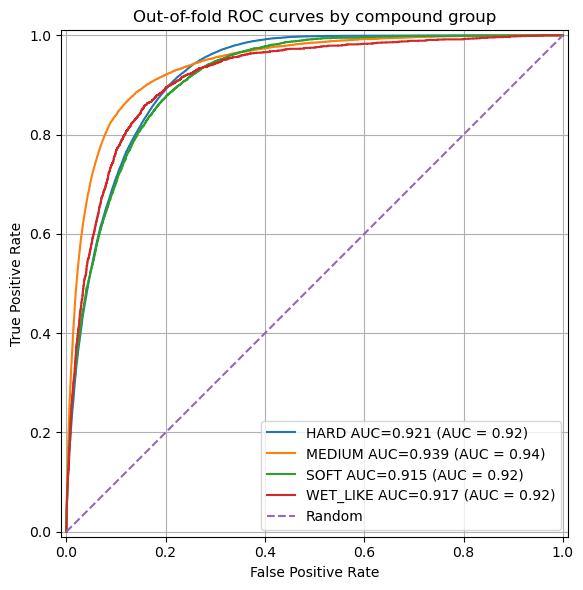

,Compound_Model,oof_roc_auc,cv_splits,n_samples,n_positive,n_negative,positive_rate
0,HARD,0.921175,5,170518,55851,114667,0.327537
1,MEDIUM,0.939470,5,211141,21353,189788,0.101131
2,SOFT,0.915081,5,38744,7496,31248,0.193475
3,WET_LIKE,0.917223,5,18737,2681,16056,0.143086


In [69]:
compound_group_roc_auc = plot_compound_group_oof_roc_curves(
    df=df,
    models=xgb_group_models,
    n_splits=5,
    random_state=42,
)

compound_group_roc_auc

In [70]:
def get_xgboost_feature_importance(
    models: dict,
    importance_type: str = "total_gain",
) -> pd.DataFrame:
    """
    Extract XGBoost feature importances
    """

    all_importances = []

    for compound_model, model_info in models.items():
        pipeline = model_info["estimator"]
        preprocessor = pipeline.named_steps["preprocessor"]
        xgb_model = pipeline.named_steps["model"]

        feature_names = preprocessor.get_feature_names_out()
        booster = xgb_model.get_booster()
        importance_dict = booster.get_score(importance_type=importance_type)

        for feature_index, feature_name in enumerate(feature_names):
            xgb_key = f"f{feature_index}"
            clean_feature_name = (
                feature_name
                .replace("categorical__", "")
                .replace("numeric__", "")
            )

            all_importances.append(
                {
                    "Compound_Model": compound_model,
                    "feature": clean_feature_name,
                    "importance": importance_dict.get(xgb_key, 0.0),
                    "importance_type": importance_type,
                }
            )

    return pd.DataFrame(all_importances)


def plot_top_xgboost_features(
    models: dict,
    top_n: int = 10,
    importance_type: str = "total_gain",
) -> pd.DataFrame:
    """
    Plot the top feature importances
    """

    importance_df = get_xgboost_feature_importance(
        models=models,
        importance_type=importance_type,
    )

    top_features = (
        importance_df
        .sort_values(["Compound_Model", "importance"], ascending=[True, False])
        .groupby("Compound_Model")
        .head(top_n)
        .reset_index(drop=True)
    )

    for compound_model in top_features["Compound_Model"].unique():
        plot_df = (
            top_features[top_features["Compound_Model"] == compound_model]
            .sort_values("importance", ascending=True)
        )

        plt.figure(figsize=(9, 5))
        plt.barh(plot_df["feature"], plot_df["importance"])
        plt.xlabel(f"Feature importance ({importance_type})")
        plt.ylabel("Feature")
        plt.title(f"Top {top_n} features - {compound_model}")
        plt.tight_layout()
        plt.show()

    return top_features


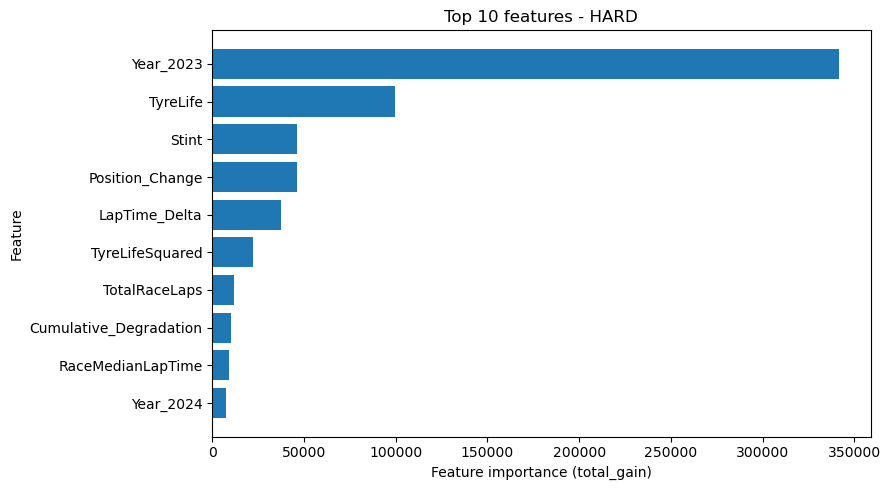

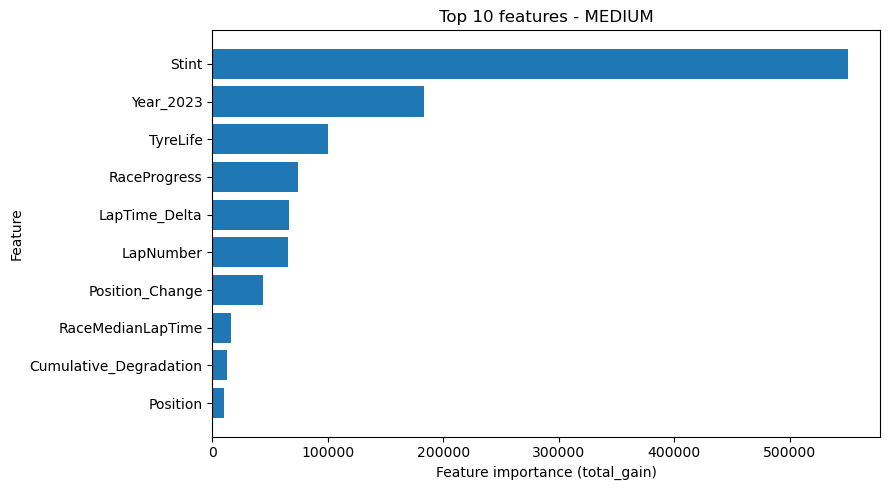

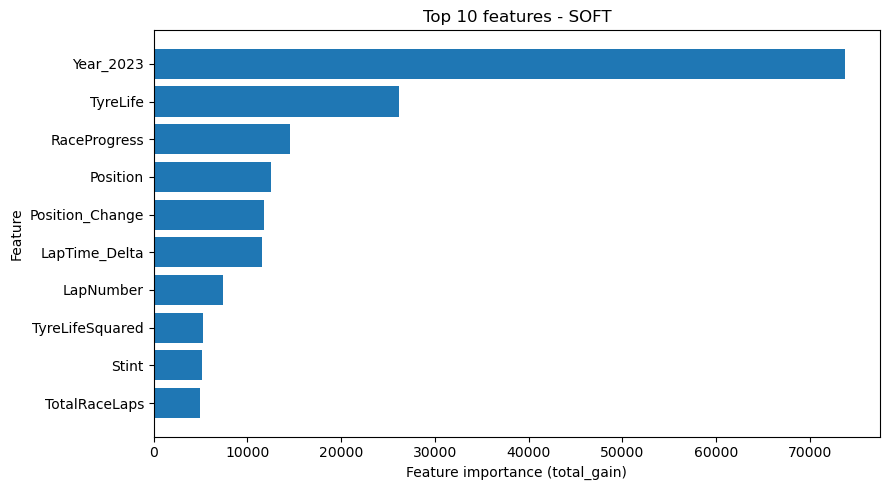

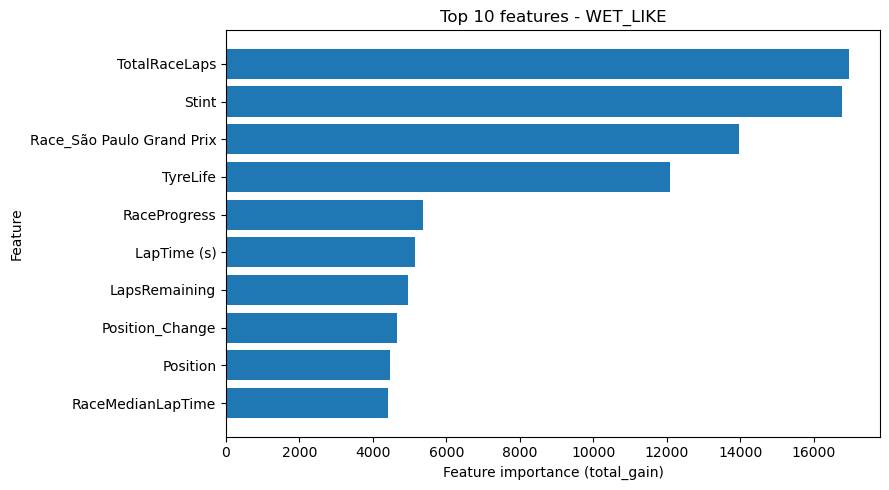

,Compound_Model,feature,importance,importance_type
0,HARD,Year_2023,341740.468750,total_gain
1,HARD,TyreLife,99865.398438,total_gain
2,HARD,Stint,46240.945312,total_gain
3,HARD,Position_Change,46230.757812,total_gain
4,HARD,LapTime_Delta,37372.371094,total_gain
5,HARD,TyreLifeSquared,22344.679688,total_gain
6,HARD,TotalRaceLaps,11592.027344,total_gain
7,HARD,Cumulative_Degradation,10302.512695,total_gain
8,HARD,RaceMedianLapTime,9330.226562,total_gain
9,HARD,Year_2024,7672.462402,total_gain


In [71]:
top_feature_plots_df = plot_top_xgboost_features(
    models=xgb_group_models,
    top_n=10,
    importance_type="total_gain",
)

top_feature_plots_df


### 8) TEST PREDICTION

In [ ]:
df_test = pd.read_csv("./data/test.csv")
df_test = add_pit_prediction_features(df_test)
df_test = add_compound_model_group(df_test)

df_test.head()

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,...,RaceProgress,Position_Change,TotalRaceLaps,LapsRemaining,TyreLifeSquared,RaceMedianLapTime,LapTimeVsRaceMedian,RecentLapTimeMean_3,RecentLapTimeTrend,Compound_Model
0,439140,D119,MEDIUM,British Grand Prix,2023,0,21,1,21.0,4,...,0.403846,0.0,66,45,441.0,93.270,0.117,94.159333,-0.772333,MEDIUM
1,439141,VER,MEDIUM,Abu Dhabi Grand Prix,2023,0,24,1,24.0,1,...,0.413793,0.0,66,42,576.0,90.631,0.236,90.189000,0.678000,MEDIUM
2,439142,D270,MEDIUM,British Grand Prix,2023,0,24,1,24.0,11,...,0.461538,0.0,66,42,576.0,93.270,-0.399,93.883333,-1.012333,MEDIUM
3,439143,D112,SOFT,São Paulo Grand Prix,2024,0,6,2,4.0,15,...,0.077922,1.0,70,64,16.0,85.061,9.906,94.967000,0.000000,SOFT
4,439144,AND,HARD,United States Grand Prix,2024,0,52,2,29.0,12,...,0.722222,7.0,61,9,841.0,100.761,-1.649,100.629000,-1.517000,HARD


In [ ]:
def predict_test_by_compound(
    df_test: pd.DataFrame,
    models: dict,
) -> pd.DataFrame:
    """
    Predict PitNextLap probabilities using multiple models
    """
    predictions = pd.Series(index=df_test.index, dtype=float)

    for compound_model, compound_df in df_test.groupby("Compound_Model"):
        if compound_model not in models:
            raise ValueError(f"No trained model available for {compound_model}")

        model_info = models[compound_model]
        feature_cols = model_info["feature_cols"]
        missing_cols = [col for col in feature_cols if col not in compound_df.columns]
        if missing_cols:
            raise ValueError(
                f"Test data is missing columns for {compound_model}: {missing_cols}"
            )

        predictions.loc[compound_df.index] = model_info["estimator"].predict_proba(
            compound_df[feature_cols]
        )[:, 1]

    if predictions.isna().any():
        missing_count = int(predictions.isna().sum())
        raise ValueError(f"Missing predictions for {missing_count} test rows")

    return pd.DataFrame(
        {
            "id": df_test["id"].astype(int),
            "PitNextLap": predictions.clip(0, 1),
        }
    )


submission = predict_test_by_compound(df_test, xgb_group_models)
submission.to_csv("./data/submission.csv", index=False)

submission.head()


,id,PitNextLap
0,439140,0.027355
1,439141,0.041421
2,439142,0.032480
3,439143,0.316826
4,439144,0.793311
